In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\sadeq\Desktop\Python\Hotel_Booking\data\hotel_bookings_clean.csv')


df['arrival_date'] = pd.to_datetime(df['arrival_date'])
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'], categories=month_order, ordered=True)

# 4.1 Booking Timeline

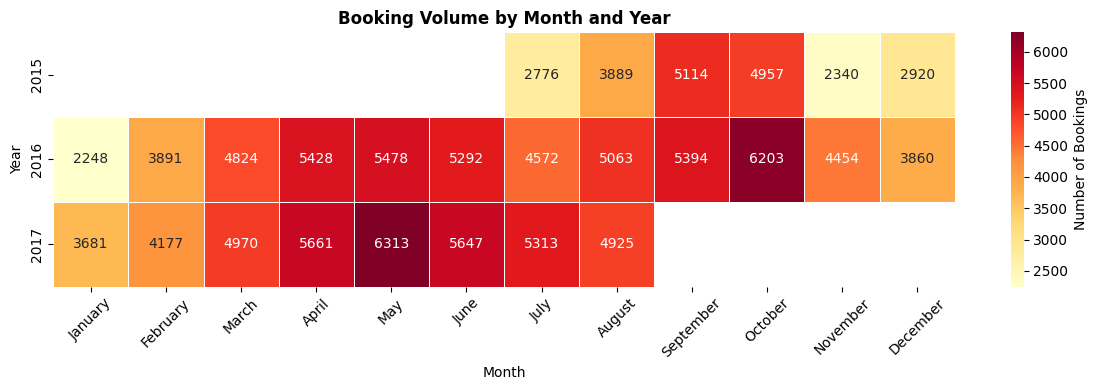

In [8]:
# 4.1.1 Booking Volume Heatmap

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

volume_pivot = (df.groupby(['arrival_date_year','arrival_date_month'])['booking_id']
                  .count()
                  .unstack()
                  .reindex(columns=month_order))
volume_pivot.index = ['2015','2016','2017']

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(volume_pivot, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            mask=volume_pivot.isna(),
            cbar_kws={'label': 'Number of Bookings'})
ax.set_title('Booking Volume by Month and Year', fontsize=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


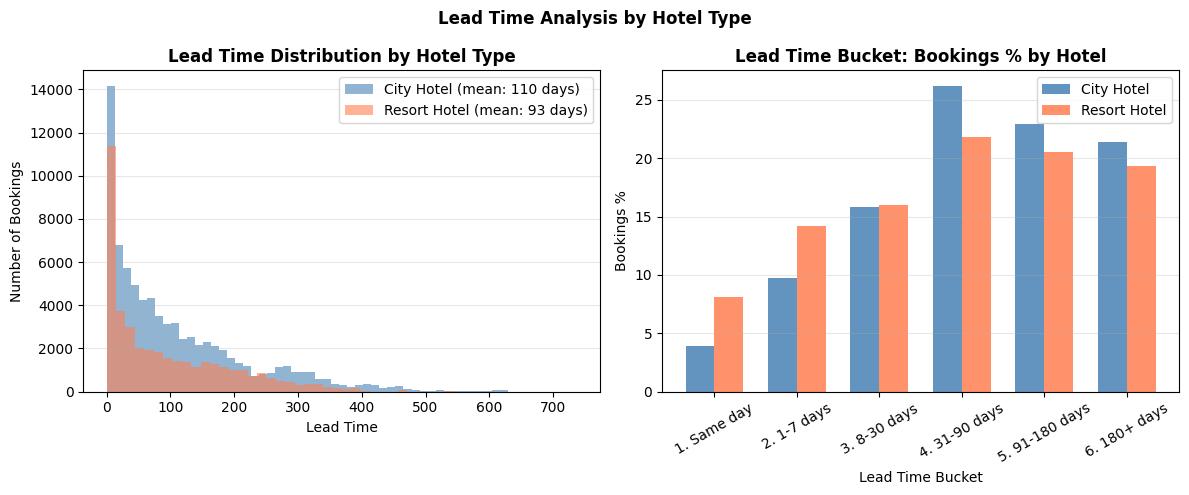

In [11]:
# 4.1.2 Lead Time Distribution by Hotel Type

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for hotel, color in [('City Hotel','steelblue'), ('Resort Hotel','coral')]:
    data = df[df['hotel'] == hotel]['lead_time']
    axes[0].hist(data, bins=50, alpha=0.6, color=color,
                 label=f"{hotel} (mean: {data.mean():.0f} days)")
axes[0].set_title('Lead Time Distribution by Hotel Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lead Time')
axes[0].set_ylabel('Number of Bookings')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)


bucket_order = ['1. Same day','2. 1-7 days','3. 8-30 days',
                '4. 31-90 days','5. 91-180 days','6. 180+ days']
lead_hotel = (df.groupby(['hotel','lead_time_bucket'])['booking_id']
                .count()
                .unstack()
                .reindex(columns=bucket_order))
lead_hotel_pct = lead_hotel.div(lead_hotel.sum(axis=1), axis=0) * 100

x = np.arange(len(bucket_order))
width = 0.35
bars1 = axes[1].bar(x - width/2, lead_hotel_pct.loc['City Hotel'],
                    width, label='City Hotel', color='steelblue', alpha=0.85)
bars2 = axes[1].bar(x + width/2, lead_hotel_pct.loc['Resort Hotel'],
                    width, label='Resort Hotel', color='coral', alpha=0.85)
axes[1].set_title('Lead Time Bucket: Bookings % by Hotel', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lead Time Bucket')
axes[1].set_ylabel('Bookings %')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bucket_order, rotation=30)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Lead Time Analysis by Hotel Type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


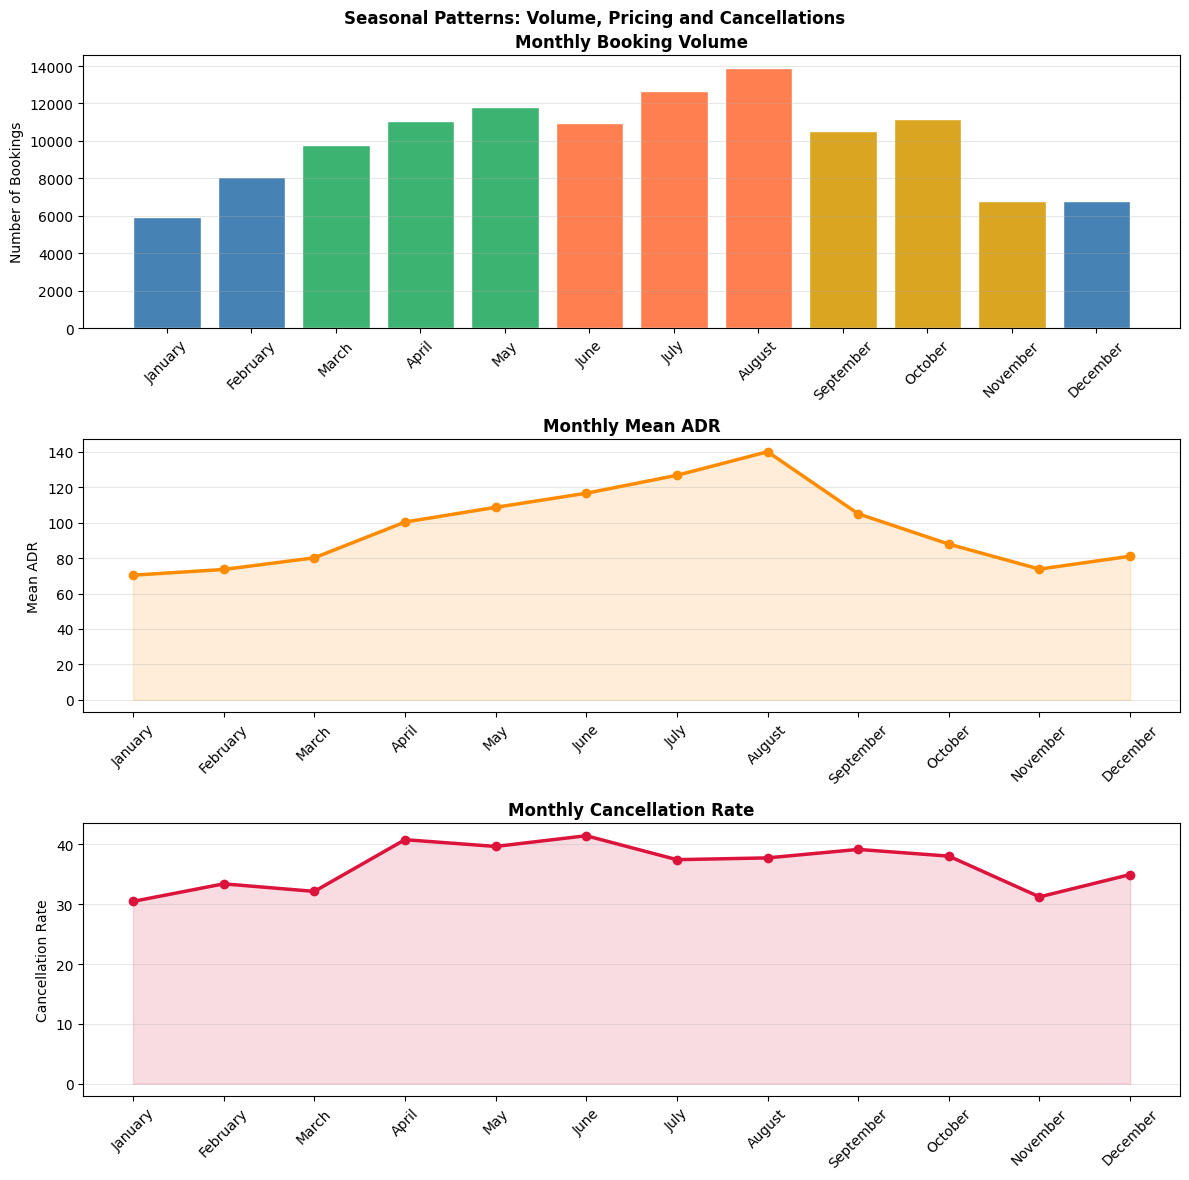

In [14]:
# 4.1.3 Seasonality Bookings and ADR by Month

monthly_stats = (df.groupby('arrival_date_month')
                   .agg(bookings=('booking_id','count'),
                        mean_adr=('adr','mean'),
                        cancellation_rate=('is_canceled','mean'))
                   .reset_index())
monthly_stats['cancellation_rate'] *= 100

fig, axes = plt.subplots(3, 1, figsize=(12, 12))


colors = ['coral' if s == 'Summer' else
          'mediumseagreen' if s == 'Spring' else
          'steelblue' if s == 'Winter' else
          'goldenrod'
          for s in df.groupby('arrival_date_month')['season'].first()]

axes[0].bar(monthly_stats['arrival_date_month'].astype(str),
            monthly_stats['bookings'], color=colors, edgecolor='white')
axes[0].set_title('Monthly Booking Volume', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Bookings')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)


axes[1].plot(monthly_stats['arrival_date_month'].astype(str),
             monthly_stats['mean_adr'],
             color='darkorange', linewidth=2.5, marker='o', markersize=6)
axes[1].fill_between(range(len(monthly_stats)),
                     monthly_stats['mean_adr'],
                     alpha=0.15, color='darkorange')
axes[1].set_title('Monthly Mean ADR', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean ADR')
axes[1].set_xticks(range(len(monthly_stats)))
axes[1].set_xticklabels(monthly_stats['arrival_date_month'].astype(str), rotation=45)
axes[1].grid(axis='y', alpha=0.3)


axes[2].plot(monthly_stats['arrival_date_month'].astype(str),
             monthly_stats['cancellation_rate'],
             color='crimson', linewidth=2.5, marker='o', markersize=6)
axes[2].fill_between(range(len(monthly_stats)),
                     monthly_stats['cancellation_rate'],
                     alpha=0.15, color='crimson')
axes[2].set_title('Monthly Cancellation Rate', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Cancellation Rate')
axes[2].set_xticks(range(len(monthly_stats)))
axes[2].set_xticklabels(monthly_stats['arrival_date_month'].astype(str), rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Seasonal Patterns: Volume, Pricing and Cancellations',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Section 4.1 Findings:
- Peak booking month is October 2016 (6,203) and May 2017 (6,313), with January consistently the slowest month
- City Hotel books further in advance (mean 110 days) vs Resort Hotel (93 days). Resort Hotel has 2× the same-day booking rate (8% vs 4%)
- Volume and ADR follow matching seasonal curves peaking in August, high demand directly drives higher pricing
- Cancellation rate is surprisingly flat year-round (30-41%), cancellation risk does not diminish in peak season, requiring consistent overbooking management throughout the year

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# 4.2  Hotel Type Performance

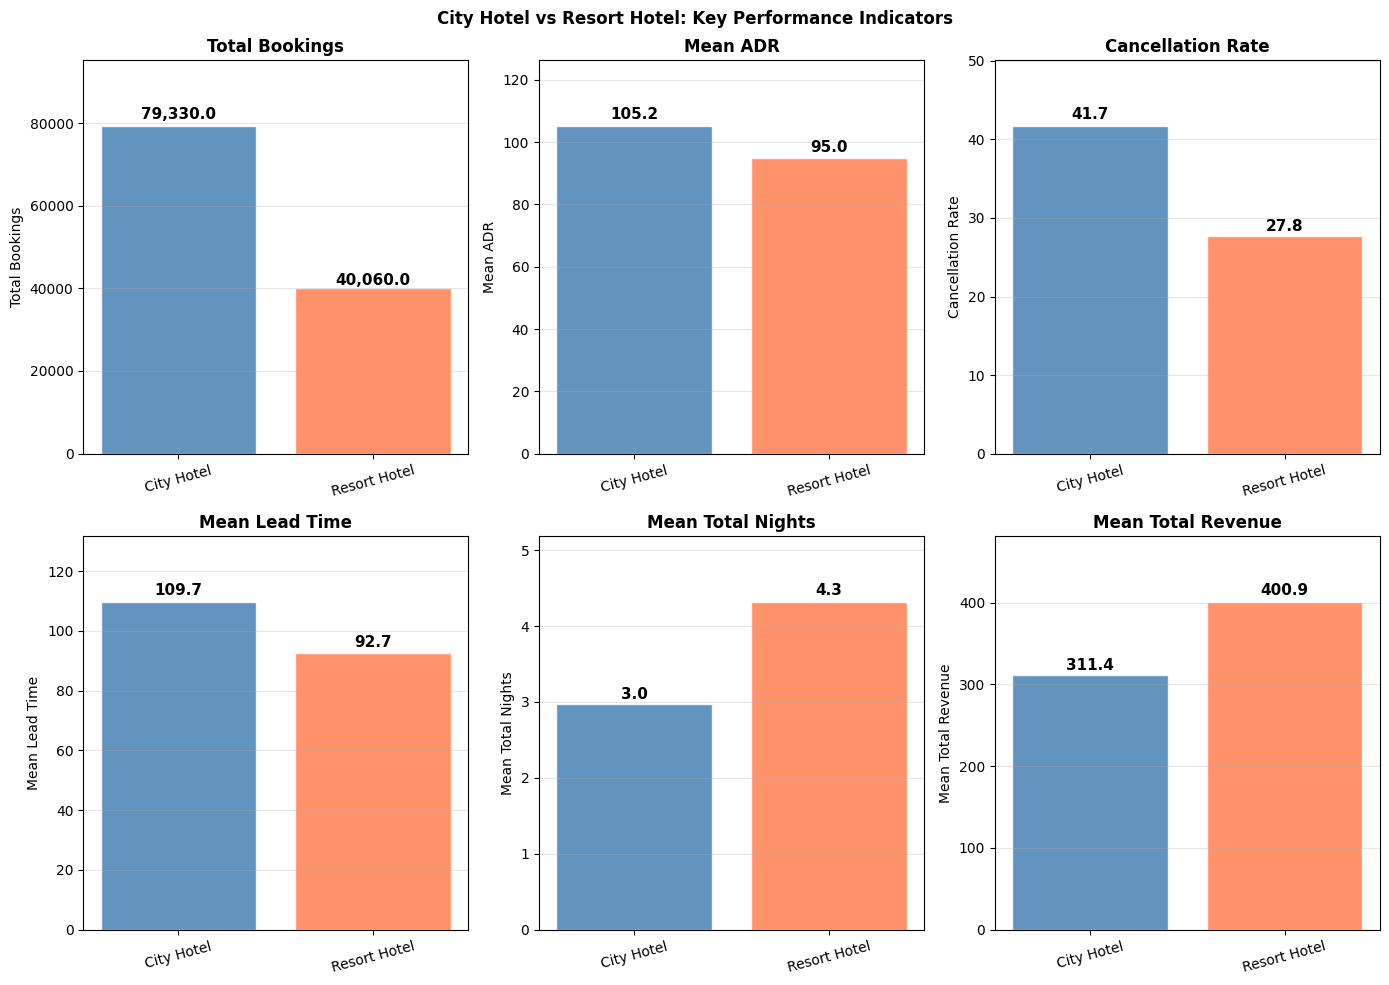

In [24]:
# 4.2.1 Hotel Type KPI Comparison

fig, axes = plt.subplots(2, 3, figsize=(14, 10))

metrics = [
    ('Total Bookings', 
     df.groupby('hotel')['booking_id'].count()),
    ('Mean ADR', 
     df.groupby('hotel')['adr'].mean()),
    ('Cancellation Rate', 
     df.groupby('hotel')['is_canceled'].mean() * 100),
    ('Mean Lead Time', 
     df.groupby('hotel')['lead_time'].mean()),
    ('Mean Total Nights', 
     df.groupby('hotel')['total_nights'].mean()),
    ('Mean Total Revenue', 
     df[df['is_canceled']==0].groupby('hotel')['total_revenue'].mean()),
]

colors = ['steelblue', 'coral']

for ax, (title, data) in zip(axes.flatten(), metrics):
    bars = ax.bar(data.index, data.values, color=colors,
                  edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:,.1f}', ha='center',
                fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, data.max() * 1.2)

plt.suptitle('City Hotel vs Resort Hotel: Key Performance Indicators',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

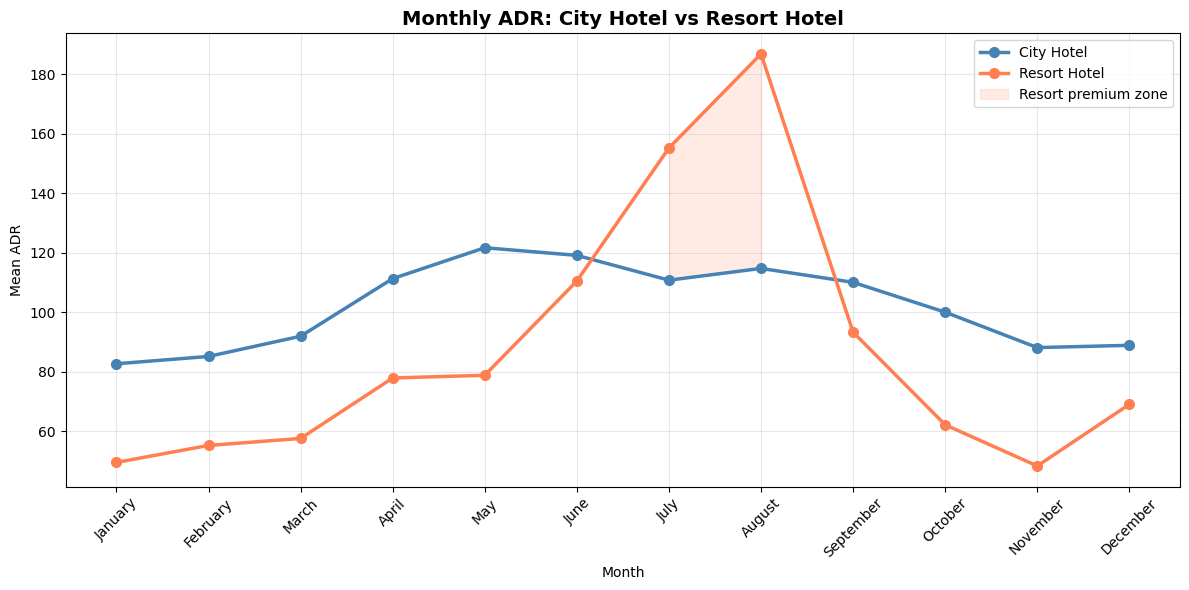

In [26]:
# 4.2.2 Monthly ADR by Hotel Type

monthly_adr = (df.groupby(['arrival_date_month', 'hotel'])['adr']
                 .mean()
                 .unstack())

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_adr.index.astype(str), monthly_adr['City Hotel'],
        color='steelblue', linewidth=2.5, marker='o',
        markersize=7, label='City Hotel')
ax.plot(monthly_adr.index.astype(str), monthly_adr['Resort Hotel'],
        color='coral', linewidth=2.5, marker='o',
        markersize=7, label='Resort Hotel')


ax.fill_between(range(len(monthly_adr)),
                monthly_adr['City Hotel'],
                monthly_adr['Resort Hotel'],
                where=monthly_adr['Resort Hotel'] > monthly_adr['City Hotel'],
                alpha=0.15, color='coral', label='Resort premium zone')

ax.set_title('Monthly ADR: City Hotel vs Resort Hotel',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Mean ADR')
ax.set_xticks(range(len(monthly_adr)))
ax.set_xticklabels(monthly_adr.index.astype(str), rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


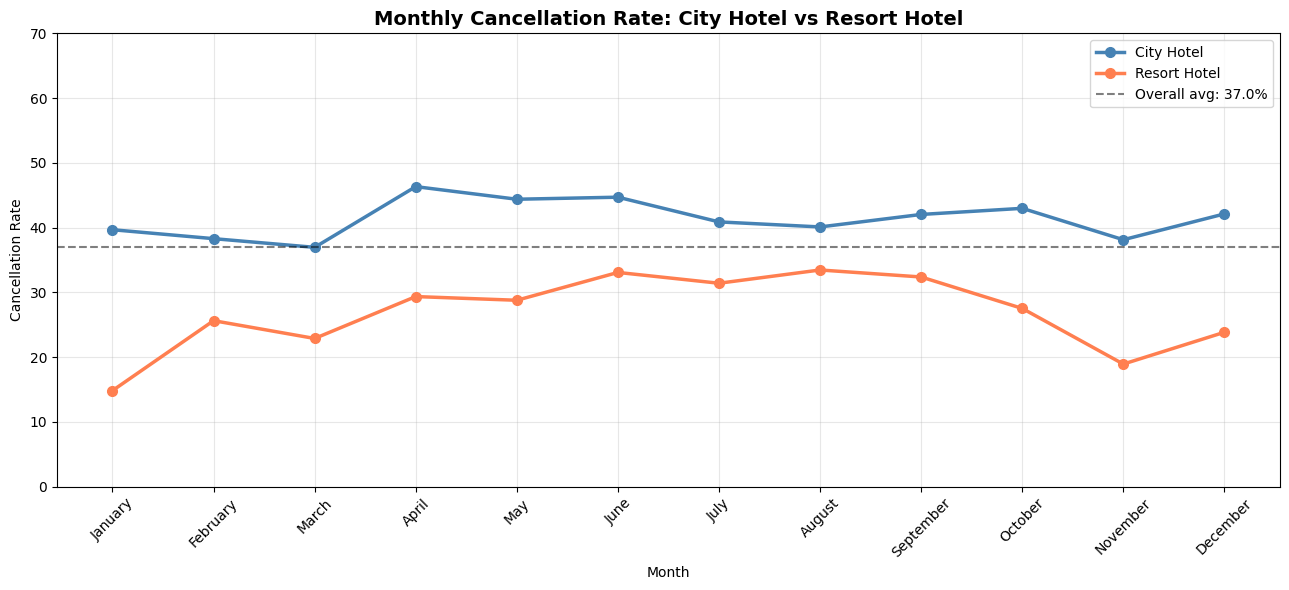

In [27]:
# 4.2.3 Cancellation Rate by Month and Hotel Type

cancel_monthly = (df.groupby(['arrival_date_month', 'hotel'])['is_canceled']
                    .mean()
                    .unstack() * 100)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(cancel_monthly.index.astype(str),
        cancel_monthly['City Hotel'],
        color='steelblue', linewidth=2.5,
        marker='o', markersize=7, label='City Hotel')
ax.plot(cancel_monthly.index.astype(str),
        cancel_monthly['Resort Hotel'],
        color='coral', linewidth=2.5,
        marker='o', markersize=7, label='Resort Hotel')

ax.axhline(y=df['is_canceled'].mean()*100,
           color='black', linestyle='--', alpha=0.5,
           label=f"Overall avg: {df['is_canceled'].mean()*100:.1f}%")

ax.set_title('Monthly Cancellation Rate: City Hotel vs Resort Hotel',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Cancellation Rate')
ax.set_xticks(range(len(cancel_monthly)))
ax.set_xticklabels(cancel_monthly.index.astype(str), rotation=45)
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 70)
plt.tight_layout()
plt.show()


Section 4.2 Findings:
- City Hotel has 2× more bookings but Resort Hotel generates higher revenue per completed stay ($400.9 vs $311.4) due to longer stays (4.3 vs 3.0 nights), ADR alone is a misleading performance metric
- Resort Hotel overtakes City Hotel ADR only in July-August, peaking at $186 in August vs City Hotel's $115 , a $71 summer premium driven by beach tourism demand
- City Hotel cancellation rate (41.7%) exceeds the overall average every single month , a structural problem requiring systematic intervention rather than seasonal adjustment
- Resort Hotel's January cancellation rate (15%) vs City Hotel (40%) reveals fundamentally different guest commitment levels in the same month

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Section 4.3 Market Segment & Channel Analysis

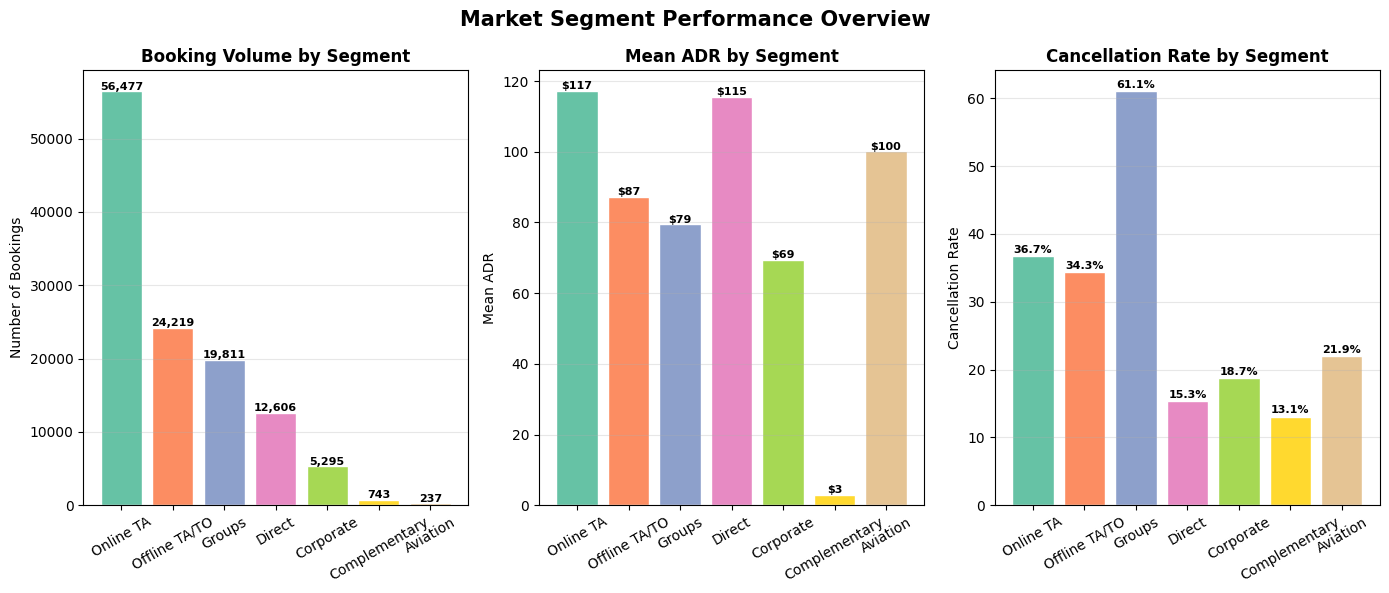

In [38]:
# 4.3.1 Market Segment Overview

segment_stats = (df.groupby('market_segment')
                   .agg(
                       bookings=('booking_id', 'count'),
                       mean_adr=('adr', 'mean'),
                       cancellation_rate=('is_canceled', 'mean'),
                       mean_nights=('total_nights', 'mean')
                   )
                   .reset_index())
segment_stats['cancellation_rate'] *= 100
segment_stats = segment_stats[~segment_stats['market_segment'].isin(['Undefined'])]
segment_stats = segment_stats.sort_values('bookings', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 6))


colors = plt.cm.Set2(range(len(segment_stats)))
bars = axes[0].bar(segment_stats['market_segment'],
                   segment_stats['bookings'],
                   color=colors, edgecolor='white')
for bar, val in zip(bars, segment_stats['bookings']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Booking Volume by Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Bookings')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)


bars2 = axes[1].bar(segment_stats['market_segment'],
                    segment_stats['mean_adr'],
                    color=colors, edgecolor='white')
for bar, val in zip(bars2, segment_stats['mean_adr']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'${val:.0f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_title('Mean ADR by Segment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean ADR')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)


bars3 = axes[2].bar(segment_stats['market_segment'],
                    segment_stats['cancellation_rate'],
                    color=colors, edgecolor='white')
for bar, val in zip(bars3, segment_stats['cancellation_rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[2].set_title('Cancellation Rate by Segment', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Cancellation Rate')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Market Segment Performance Overview',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


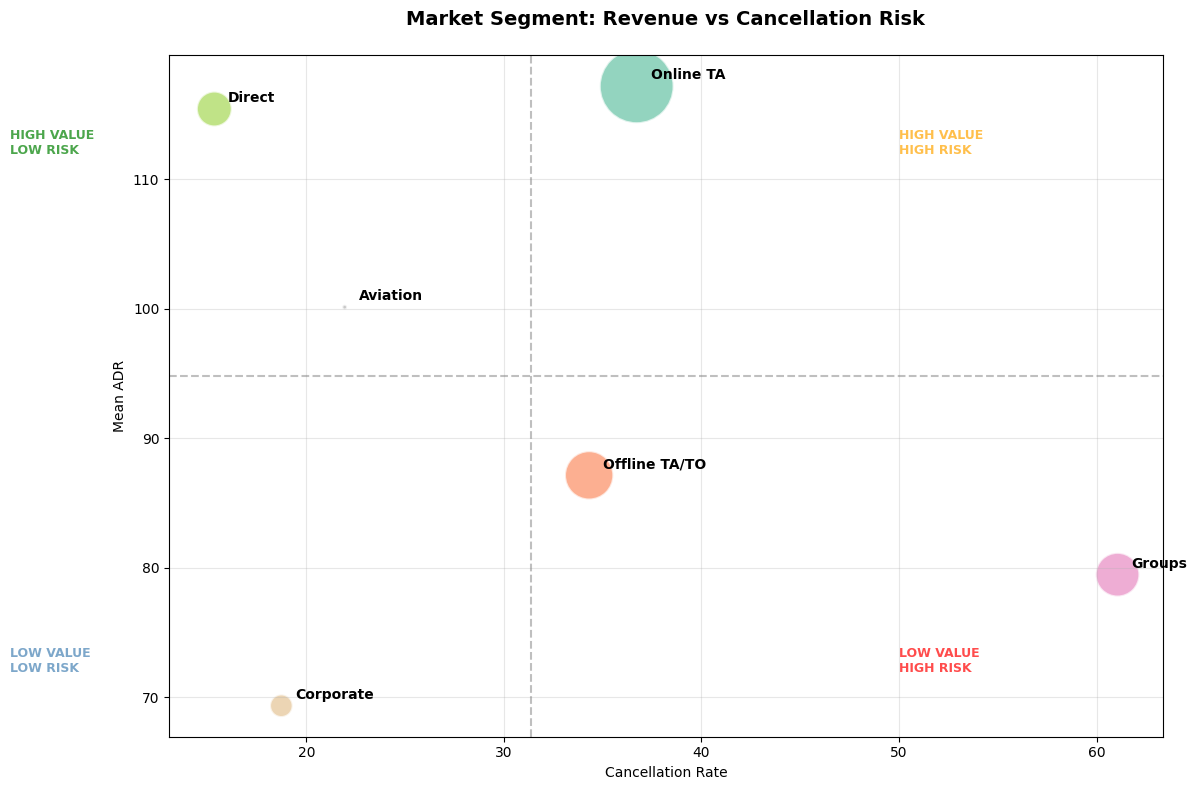

In [ ]:
# 4.3.2 Revenue vs Risk

segment_revenue = (df[df['is_canceled']==0]
                   .groupby('market_segment')['total_revenue']
                   .sum()
                   .reset_index())
segment_revenue.columns = ['market_segment', 'total_revenue']

bubble_data = segment_stats.merge(segment_revenue, on='market_segment')
bubble_data = bubble_data[bubble_data['market_segment'] != 'Complementary']

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    bubble_data['cancellation_rate'],
    bubble_data['mean_adr'],
    s=bubble_data['bookings'] / 20,
    c=range(len(bubble_data)),
    cmap='Set2',
    alpha=0.7,
    edgecolors='white',
    linewidth=1.5
)

for _, row in bubble_data.iterrows():
    ax.annotate(row['market_segment'],
                (row['cancellation_rate'], row['mean_adr']),
                textcoords='offset points',
                xytext=(10, 5),
                fontsize=10,
                fontweight='bold')


ax.axvline(x=bubble_data['cancellation_rate'].mean(),
           color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=bubble_data['mean_adr'].mean(),
           color='gray', linestyle='--', alpha=0.5)


ax.text(5, 112, 'HIGH VALUE\nLOW RISK', fontsize=9,
        color='green', fontweight='bold', alpha=0.7)
ax.text(50, 112, 'HIGH VALUE\nHIGH RISK', fontsize=9,
        color='orange', fontweight='bold', alpha=0.7)
ax.text(5, 72, 'LOW VALUE\nLOW RISK', fontsize=9,
        color='steelblue', fontweight='bold', alpha=0.7)
ax.text(50, 72, 'LOW VALUE\nHIGH RISK', fontsize=9,
        color='red', fontweight='bold', alpha=0.7)

ax.set_title('Market Segment: Revenue vs Cancellation Risk\n'
             ,
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cancellation Rate')
ax.set_ylabel('Mean ADR')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

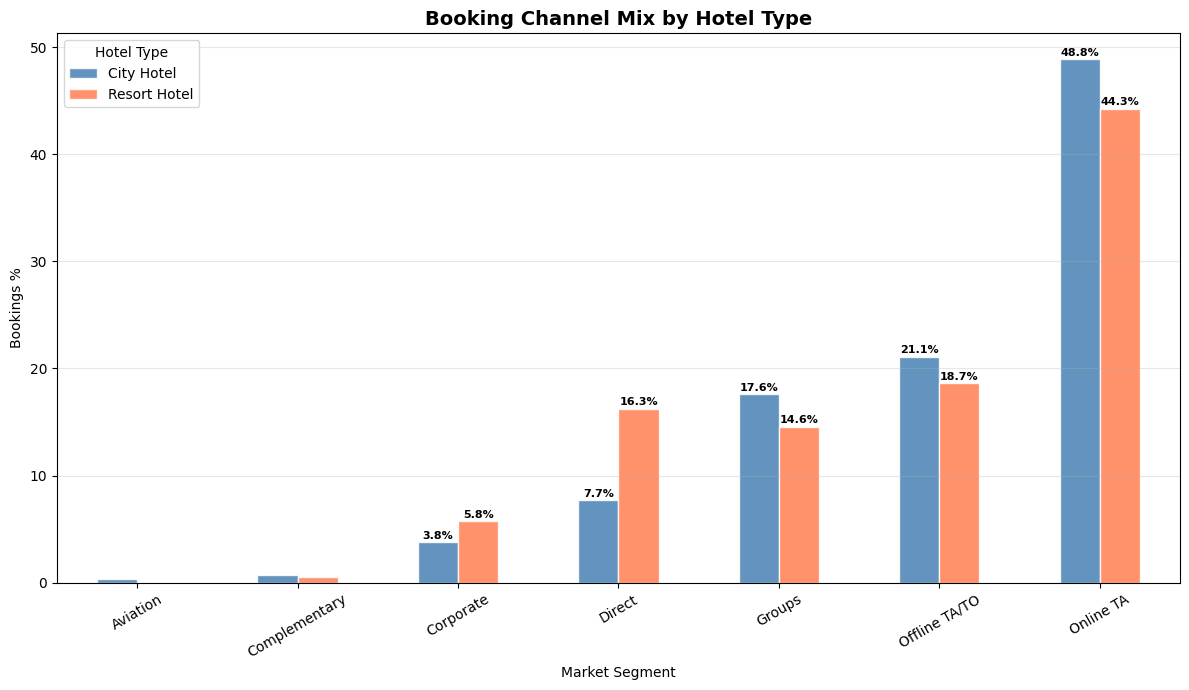

In [40]:
# 4.3.3 Booking Channel Mix by Hotel Type

channel_mix = (df.groupby(['hotel', 'market_segment'])['booking_id']
                 .count()
                 .unstack()
                 .drop(columns=['Undefined'], errors='ignore')
                 .fillna(0))

channel_mix_pct = channel_mix.div(channel_mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))

channel_mix_pct.T.plot(
    kind='bar',
    ax=ax,
    color=['steelblue', 'coral'],
    edgecolor='white',
    alpha=0.85
)

ax.set_title('Booking Channel Mix by Hotel Type',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Market Segment')
ax.set_ylabel('Bookings %')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Hotel Type')
ax.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    if bar.get_height() > 1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%',
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


Section 4.3 Findings:
- Online TA dominates volume (47% of bookings) with premium ADR ($117) but 36.7% cancellation rate, high reward, high risk
- Direct bookings are the ideal segment, near-identical ADR to Online TA ($115) with only 15.3% cancellation and zero OTA commission cost
- Groups is the most problematic segment — lowest ADR among paying segments ($79) combined with the highest cancellation rate (61.1%)
- Both hotels are heavily OTA-dependent (City: 48.8%, Resort: 44.3%), growing direct bookings is the single highest-ROI channel strategy
- Resort Hotel achieves more than double City Hotel's direct booking rate (16.3% vs 7.7%) , a model City Hotel should replicate

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Section 4.4  Cancellation Deep Dive

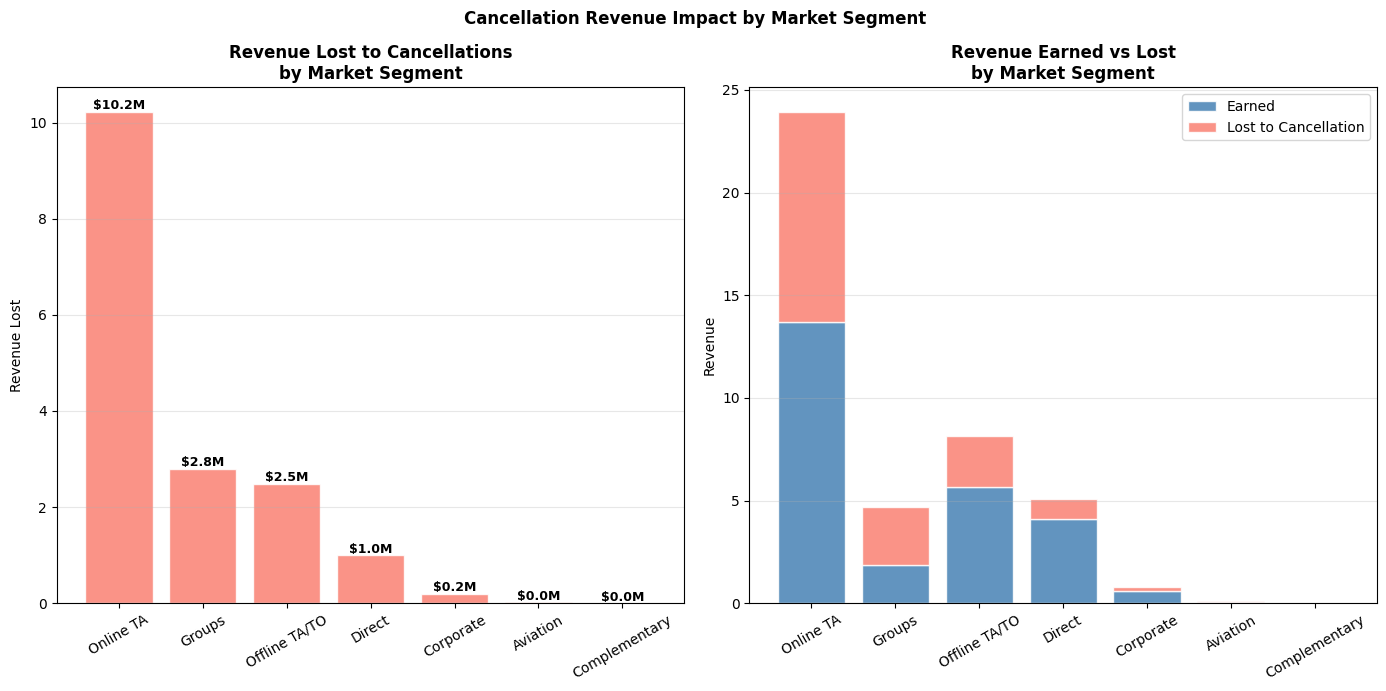

In [47]:
# 4.4.1 Revenue Lost to Cancellations by Segment

revenue_lost = (df[df['is_canceled'] == 1]
                .groupby('market_segment')['total_revenue']
                .sum()
                .sort_values(ascending=False)
                .reset_index())
revenue_lost.columns = ['segment', 'revenue_lost']
revenue_lost = revenue_lost[revenue_lost['segment'] != 'Undefined']
revenue_lost['revenue_lost_m'] = revenue_lost['revenue_lost'] / 1_000_000

revenue_earned = (df[df['is_canceled'] == 0]
                  .groupby('market_segment')['total_revenue']
                  .sum()
                  .reset_index())
revenue_earned.columns = ['segment', 'revenue_earned']
revenue_earned['revenue_earned_m'] = revenue_earned['revenue_earned'] / 1_000_000

rev_combined = revenue_lost.merge(revenue_earned, on='segment')
rev_combined['loss_pct'] = (rev_combined['revenue_lost'] /
                            (rev_combined['revenue_lost'] +
                             rev_combined['revenue_earned'])) * 100
rev_combined = rev_combined.sort_values('revenue_lost_m', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))


bars = axes[0].bar(rev_combined['segment'],
                   rev_combined['revenue_lost_m'],
                   color='salmon', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, rev_combined['revenue_lost_m']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'${val:.1f}M', ha='center',
                 fontweight='bold', fontsize=9)
axes[0].set_title('Revenue Lost to Cancellations\nby Market Segment',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue Lost')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)


axes[1].bar(rev_combined['segment'],
            rev_combined['revenue_earned_m'],
            color='steelblue', edgecolor='white',
            alpha=0.85, label='Earned')
axes[1].bar(rev_combined['segment'],
            rev_combined['revenue_lost_m'],
            bottom=rev_combined['revenue_earned_m'],
            color='salmon', edgecolor='white',
            alpha=0.85, label='Lost to Cancellation')
axes[1].set_title('Revenue Earned vs Lost\nby Market Segment',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Cancellation Revenue Impact by Market Segment',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


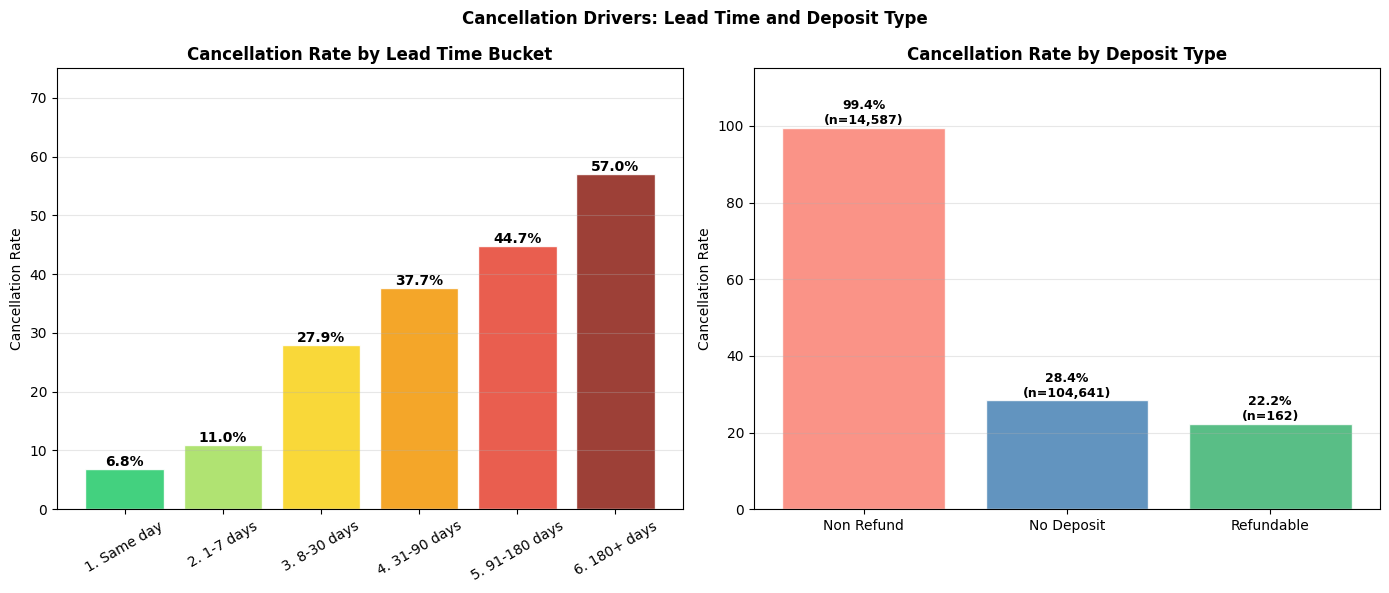

In [49]:
# 4.4.2 Cancellation Drivers:Lead Time and Deposit Type

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


bucket_order = ['1. Same day','2. 1-7 days','3. 8-30 days',
                '4. 31-90 days','5. 91-180 days','6. 180+ days']
cancel_lead = (df.groupby('lead_time_bucket')['is_canceled']
                 .mean()
                 .reindex(bucket_order) * 100)

colors_gradient = ['#2ecc71','#a8e063','#f9d423','#f39c12','#e74c3c','#922b21']
bars = axes[0].bar(cancel_lead.index, cancel_lead.values,
                   color=colors_gradient, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, cancel_lead.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center',
                 fontweight='bold', fontsize=10)
axes[0].set_title('Cancellation Rate by Lead Time Bucket',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cancellation Rate')
axes[0].set_ylim(0, 75)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)


deposit_stats = (df.groupby('deposit_type')
                   .agg(cancel_rate=('is_canceled','mean'),
                        total=('booking_id','count'),
                        cancelled=('is_canceled','sum'))
                   .reset_index())
deposit_stats['cancel_rate'] *= 100
deposit_stats = deposit_stats.sort_values('cancel_rate', ascending=False)

colors_dep = ['salmon','steelblue','mediumseagreen']
bars2 = axes[1].bar(deposit_stats['deposit_type'],
                    deposit_stats['cancel_rate'],
                    color=colors_dep, edgecolor='white', alpha=0.85)
for bar, row in zip(bars2, deposit_stats.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{row.cancel_rate:.1f}%\n(n={row.total:,})',
                 ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Cancellation Rate by Deposit Type',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cancellation Rate')
axes[1].set_ylim(0, 115)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Cancellation Drivers: Lead Time and Deposit Type',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

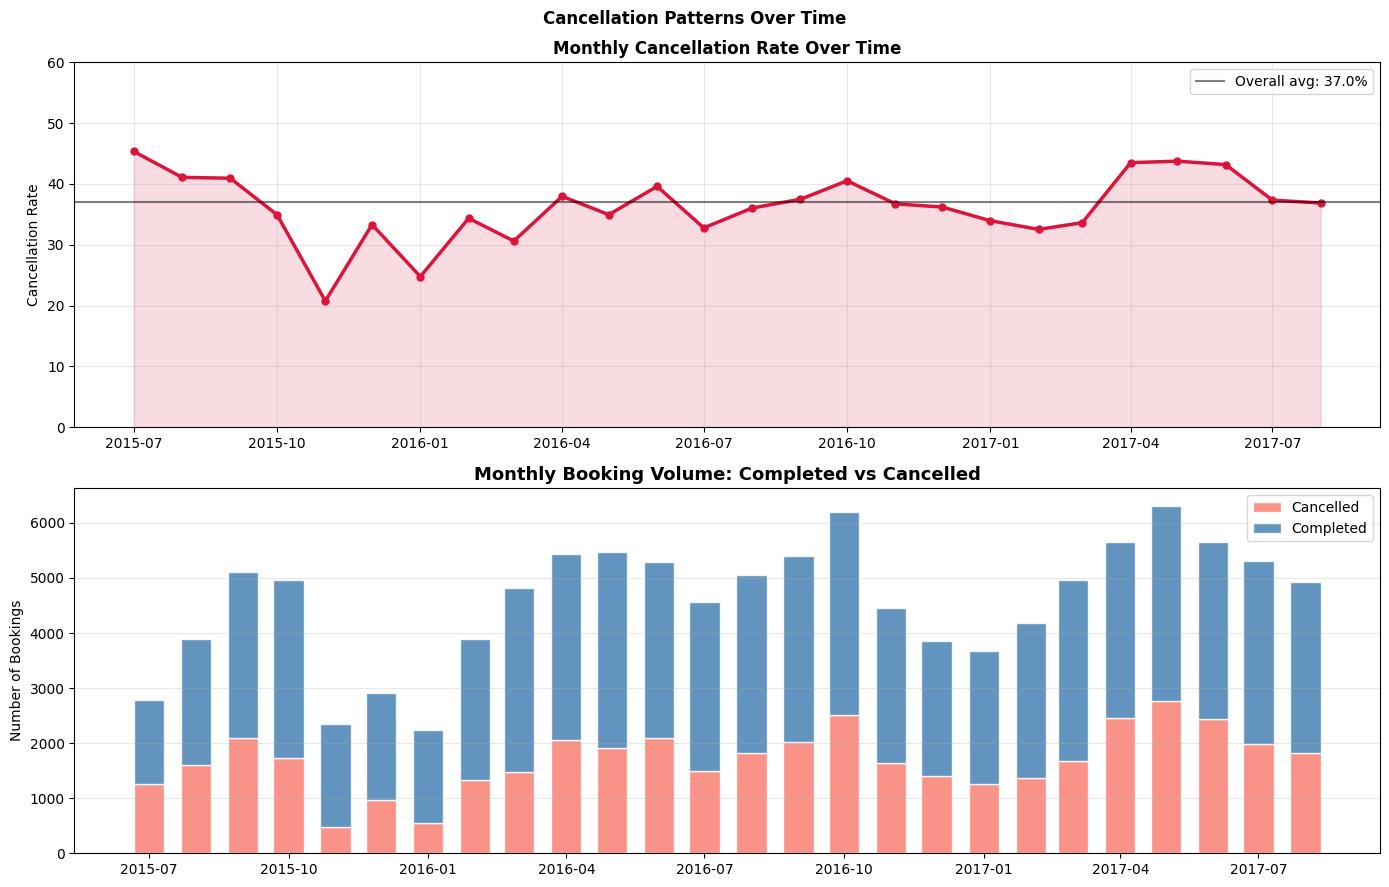

In [53]:
# 4.4.3 Cancellation Rate Over Time

monthly_cancel = (df.groupby(['arrival_date_year',
                               'arrival_date_month'])['is_canceled']
                    .agg(['mean','sum','count'])
                    .reset_index())
monthly_cancel.columns = ['year','month','cancel_rate',
                           'cancelled','total']
monthly_cancel['cancel_rate'] *= 100
monthly_cancel['date'] = pd.to_datetime(
    monthly_cancel['year'].astype(str) + '-' +
    monthly_cancel['month'].astype(str) + '-01')
monthly_cancel = monthly_cancel.sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 9))


axes[0].plot(monthly_cancel['date'],
             monthly_cancel['cancel_rate'],
             color='crimson', linewidth=2.5,
             marker='o', markersize=5)
axes[0].fill_between(monthly_cancel['date'],
                     monthly_cancel['cancel_rate'],
                     alpha=0.15, color='crimson')
axes[0].axhline(y=37.0, color='black',
                alpha=0.5, label='Overall avg: 37.0%')
axes[0].set_title('Monthly Cancellation Rate Over Time',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cancellation Rate')
axes[0].set_ylim(0, 60)
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].bar(monthly_cancel['date'],
            monthly_cancel['cancelled'],
            color='salmon', edgecolor='white',
            alpha=0.85, width=20)
axes[1].bar(monthly_cancel['date'],
            monthly_cancel['total'] - monthly_cancel['cancelled'],
            bottom=monthly_cancel['cancelled'],
            color='steelblue', edgecolor='white',
            alpha=0.85, width=20, label='Completed')
axes[1].set_title('Monthly Booking Volume: Completed vs Cancelled',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Bookings')
axes[1].legend(['Cancelled','Completed'])
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Cancellation Patterns Over Time',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

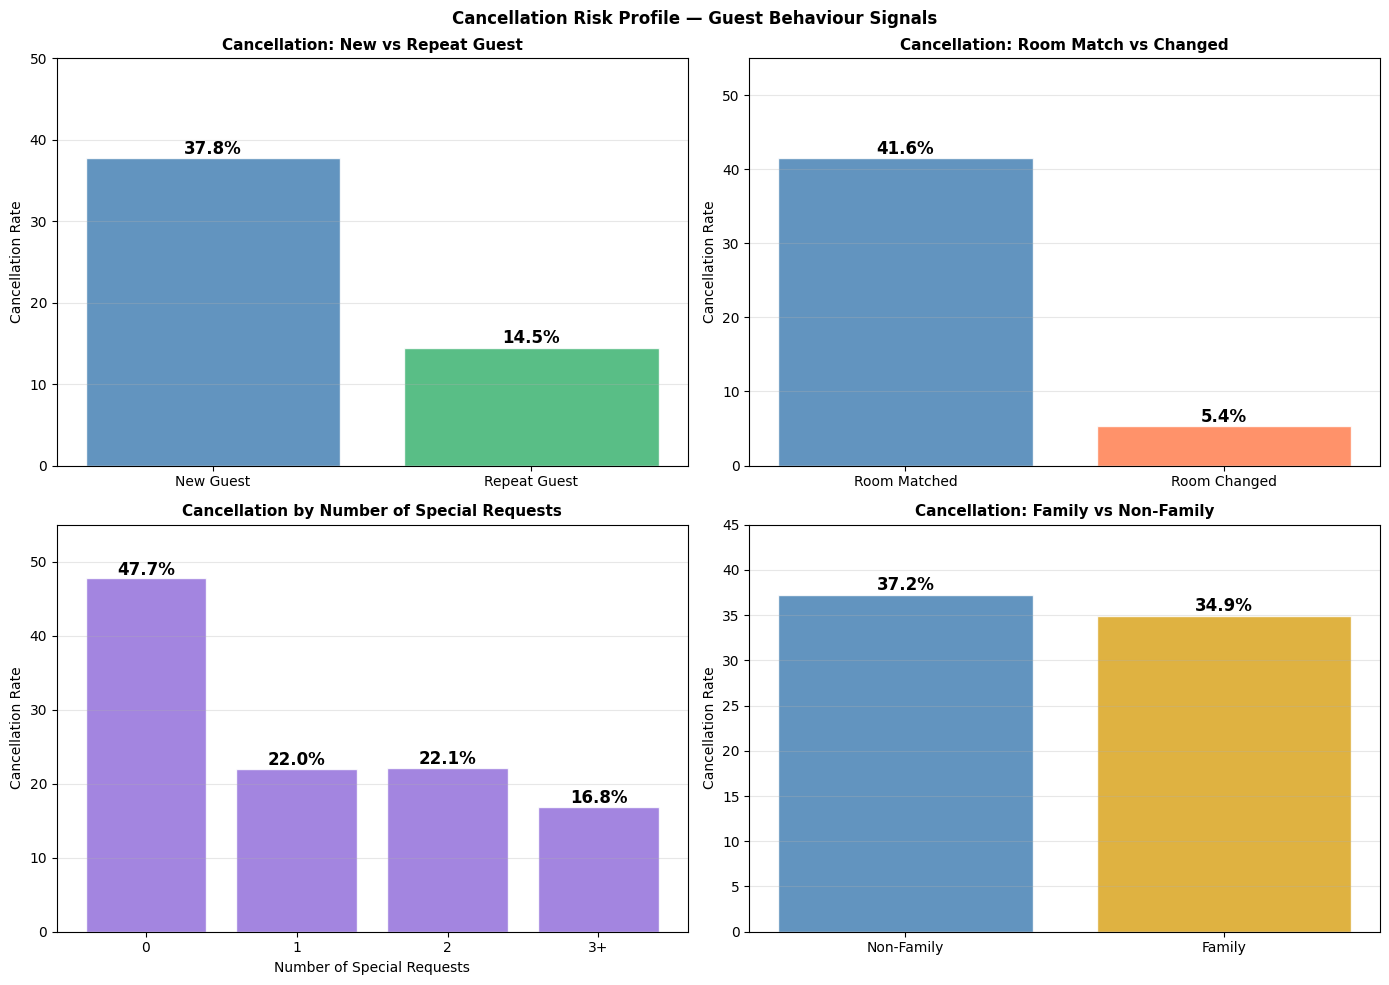

In [ ]:
# 4.4.4 Cancellation Risk Profile

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


labels = ['New Guest','Repeat Guest']
vals = [df[df['is_repeated_guest']==0]['is_canceled'].mean()*100,
        df[df['is_repeated_guest']==1]['is_canceled'].mean()*100]
bars = axes[0,0].bar(labels, vals,
                     color=['steelblue','mediumseagreen'],
                     edgecolor='white', alpha=0.85)
for bar, val in zip(bars, vals):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center',
                   fontweight='bold', fontsize=12)
axes[0,0].set_title('Cancellation: New vs Repeat Guest',
                    fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Cancellation Rate')
axes[0,0].set_ylim(0, 50)
axes[0,0].grid(axis='y', alpha=0.3)


labels2 = ['Room Matched','Room Changed']
vals2 = [df[df['room_match']==1]['is_canceled'].mean()*100,
         df[df['room_match']==0]['is_canceled'].mean()*100]
bars2 = axes[0,1].bar(labels2, vals2,
                      color=['steelblue','coral'],
                      edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, vals2):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center',
                   fontweight='bold', fontsize=12)
axes[0,1].set_title('Cancellation: Room Match vs Changed',
                    fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Cancellation Rate')
axes[0,1].set_ylim(0, 55)
axes[0,1].grid(axis='y', alpha=0.3)


df['special_req_group'] = pd.cut(df['total_of_special_requests'],
                                  bins=[-1,0,1,2,5],
                                  labels=['0','1','2','3+'])
cancel_req = (df.groupby('special_req_group')['is_canceled']
                .mean() * 100)
bars3 = axes[1,0].bar(cancel_req.index.astype(str),
                      cancel_req.values,
                      color='mediumpurple', edgecolor='white', alpha=0.85)
for bar, val in zip(bars3, cancel_req.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center',
                   fontweight='bold', fontsize=12)
axes[1,0].set_title('Cancellation by Number of Special Requests',
                    fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Number of Special Requests')
axes[1,0].set_ylabel('Cancellation Rate')
axes[1,0].set_ylim(0, 55)
axes[1,0].grid(axis='y', alpha=0.3)


labels4 = ['Non-Family','Family']
vals4 = [df[df['is_family']==0]['is_canceled'].mean()*100,
         df[df['is_family']==1]['is_canceled'].mean()*100]
bars4 = axes[1,1].bar(labels4, vals4,
                      color=['steelblue','goldenrod'],
                      edgecolor='white', alpha=0.85)
for bar, val in zip(bars4, vals4):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center',
                   fontweight='bold', fontsize=12)
axes[1,1].set_title('Cancellation: Family vs Non-Family',
                    fontsize=11, fontweight='bold')
axes[1,1].set_ylabel('Cancellation Rate')
axes[1,1].set_ylim(0, 45)
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Cancellation Risk Profile: Guest Behaviour Signals',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Section 4.4 Findings:
- Online TA accounts for $10.2M in lost revenue, 61% of all cancellation revenue loss — driven by high volume × moderate cancellation rate combination
- Cancellation rate increases monotonically with lead time (6.8% to 57.0%) the single most reliable cancellation predictor
- Cancellation rate is structurally flat at ~37% throughout the entire dataset period, the problem is persistent, not seasonal
- Special requests are a powerful commitment signal guests with zero requests cancel at 47.7% vs 16.8% for guests with 3+ requests, a 31 percentage point difference
- Room-changed guests cancel at only 5.4% vs 41.6% for matched rooms, strategic upgrades are the most effective cancellation reduction tool
- Family bookings show no meaningful cancellation advantage (34.9% vs 37.2%) despite higher ADR, family status alone is not a risk signal

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Section 4.5 Revenue & Pricing Analysis

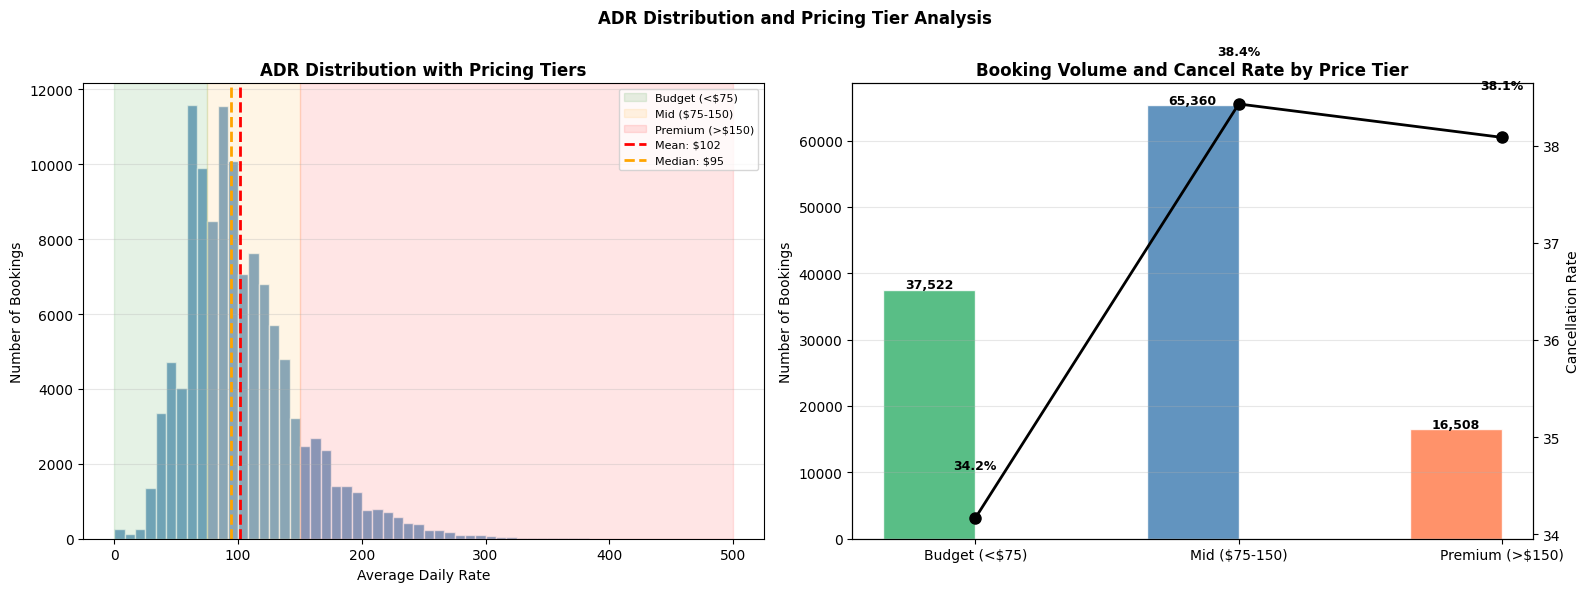

In [64]:
# 4.5.1 ADR Distribution and Pricing Tiers

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].hist(df[df['adr'] > 0]['adr'], bins=60,
             color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvspan(0, 75, alpha=0.1, color='green', label='Budget (<$75)')
axes[0].axvspan(75, 150, alpha=0.1, color='orange', label='Mid ($75-150)')
axes[0].axvspan(150, 500, alpha=0.1, color='red', label='Premium (>$150)')
axes[0].axvline(df['adr'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: ${df['adr'].mean():.0f}")
axes[0].axvline(df['adr'].median(), color='orange', linestyle='--',
                linewidth=2, label=f"Median: ${df['adr'].median():.0f}")
axes[0].set_title('ADR Distribution with Pricing Tiers',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Daily Rate')
axes[0].set_ylabel('Number of Bookings')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)


df['price_tier'] = pd.cut(df['adr'],
                           bins=[-1, 75, 150, 500],
                           labels=['Budget (<$75)',
                                   'Mid ($75-150)',
                                   'Premium (>$150)'])
tier_stats = (df.groupby('price_tier', observed=True)
                .agg(bookings=('booking_id','count'),
                     cancel_rate=('is_canceled','mean'))
                .reset_index())
tier_stats['cancel_rate'] *= 100

x = np.arange(len(tier_stats))
width = 0.35
axes[1].bar(x - width/2, tier_stats['bookings'],
            width, color=['mediumseagreen','steelblue','coral'],
            edgecolor='white', alpha=0.85, label='Bookings')
ax2 = axes[1].twinx()
ax2.plot(x, tier_stats['cancel_rate'],
         color='black', marker='o', linewidth=2,
         markersize=8, label='Cancel Rate %')
for i, (b, c) in enumerate(zip(tier_stats['bookings'],
                                tier_stats['cancel_rate'])):
    axes[1].text(i - width/2, b + 200, f'{b:,}',
                 ha='center', fontsize=9, fontweight='bold')
    ax2.text(i, c + 0.5, f'{c:.1f}%',
             ha='center', fontsize=9, fontweight='bold', color='black')
axes[1].set_title('Booking Volume and Cancel Rate by Price Tier',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Bookings')
ax2.set_ylabel('Cancellation Rate')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tier_stats['price_tier'])
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('ADR Distribution and Pricing Tier Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



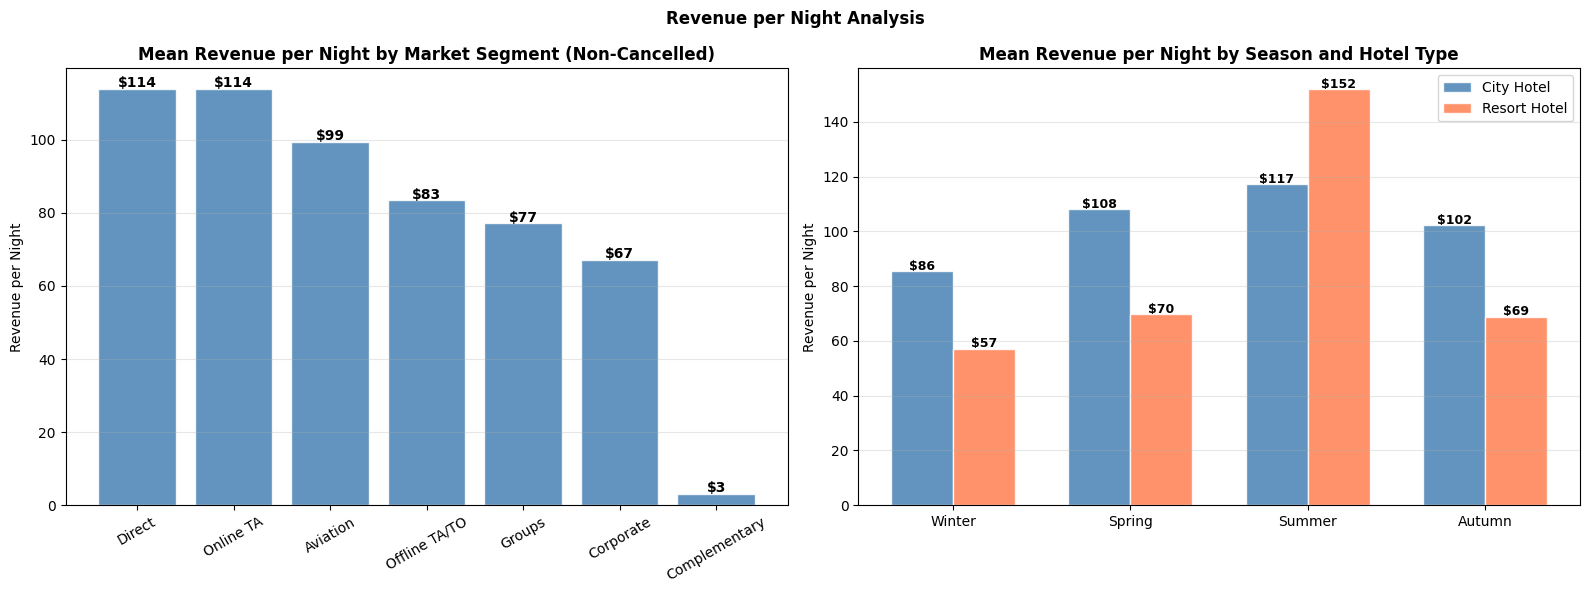

In [67]:
# 4.5.2 Revenue per Night by Segment and Season

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


rpn_segment = (df[df['is_canceled']==0]
               .groupby('market_segment')['revenue_per_night']
               .mean()
               .sort_values(ascending=False)
               .drop('Undefined', errors='ignore'))

bars = axes[0].bar(rpn_segment.index, rpn_segment.values,
                   color='steelblue', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, rpn_segment.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'${val:.0f}', ha='center',
                 fontweight='bold', fontsize=10)
axes[0].set_title('Mean Revenue per Night by Market Segment (Non-Cancelled)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue per Night')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)


rpn_season = (df[df['is_canceled']==0]
              .groupby(['season','hotel'])['revenue_per_night']
              .mean()
              .unstack())
season_order = ['Winter','Spring','Summer','Autumn']
rpn_season = rpn_season.reindex(season_order)

x = np.arange(len(season_order))
width = 0.35
axes[1].bar(x - width/2, rpn_season['City Hotel'],
            width, label='City Hotel',
            color='steelblue', edgecolor='white', alpha=0.85)
axes[1].bar(x + width/2, rpn_season['Resort Hotel'],
            width, label='Resort Hotel',
            color='coral', edgecolor='white', alpha=0.85)
for i, (c, r) in enumerate(zip(rpn_season['City Hotel'],
                                rpn_season['Resort Hotel'])):
    axes[1].text(i - width/2, c + 0.5, f'${c:.0f}',
                 ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + width/2, r + 0.5, f'${r:.0f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Mean Revenue per Night by Season and Hotel Type',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue per Night')
axes[1].set_xticks(x)
axes[1].set_xticklabels(season_order)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Revenue per Night Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



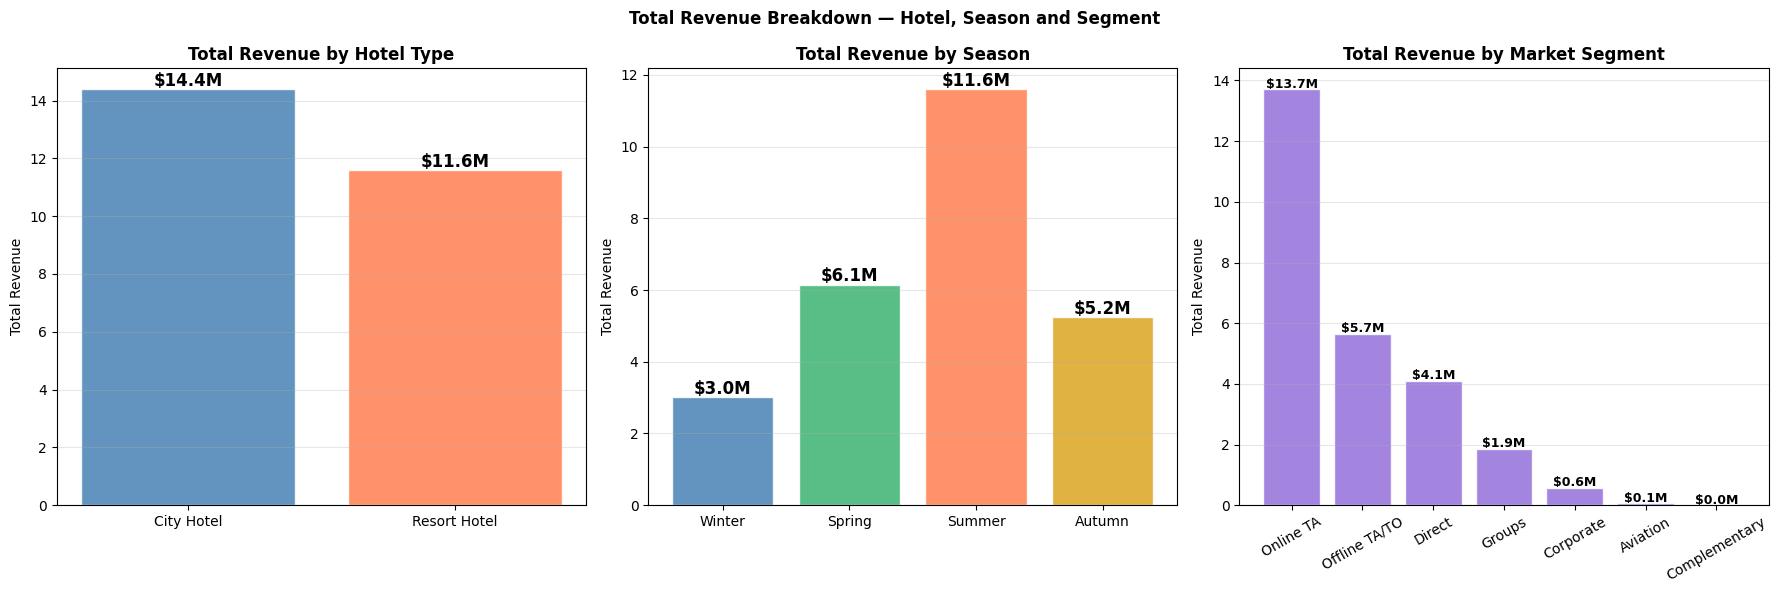

In [70]:
# 4.5.3 Total Revenue Breakdown

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


rev_hotel = (df[df['is_canceled']==0]
             .groupby('hotel')['total_revenue']
             .sum() / 1_000_000)
bars = axes[0].bar(rev_hotel.index, rev_hotel.values,
                   color=['steelblue','coral'],
                   edgecolor='white', alpha=0.85)
for bar, val in zip(bars, rev_hotel.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'${val:.1f}M', ha='center',
                 fontweight='bold', fontsize=12)
axes[0].set_title('Total Revenue by Hotel Type',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Revenue')
axes[0].grid(axis='y', alpha=0.3)


rev_season = (df[df['is_canceled']==0]
              .groupby('season')['total_revenue']
              .sum()
              .reindex(['Winter','Spring','Summer','Autumn']) / 1_000_000)
colors_s = ['steelblue','mediumseagreen','coral','goldenrod']
bars2 = axes[1].bar(rev_season.index, rev_season.values,
                    color=colors_s, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, rev_season.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'${val:.1f}M', ha='center',
                 fontweight='bold', fontsize=12)
axes[1].set_title('Total Revenue by Season',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Revenue')
axes[1].grid(axis='y', alpha=0.3)


rev_segment = (df[df['is_canceled']==0]
               .groupby('market_segment')['total_revenue']
               .sum()
               .sort_values(ascending=False)
               .drop('Undefined', errors='ignore') / 1_000_000)
bars3 = axes[2].bar(rev_segment.index, rev_segment.values,
                    color='mediumpurple', edgecolor='white', alpha=0.85)
for bar, val in zip(bars3, rev_segment.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'${val:.1f}M', ha='center',
                 fontweight='bold', fontsize=9)
axes[2].set_title('Total Revenue by Market Segment',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Total Revenue')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Total Revenue Breakdown — Hotel, Season and Segment',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Section 4.5 Findings:
- Price tier does not predict cancellation — Budget (34.2%), Mid (38.4%), and Premium (38.1%) cancel at virtually identical rates. ADR is not a cancellation risk signal.
- Direct and Online TA generate identical revenue per night ($114), direct booking conversion costs nothing in rate competitiveness while eliminating 15-20% OTA commission
- Summer generates $11.6M — 45% of total annual revenue creating extreme seasonal concentration risk
- Online TA accounts for 54% of total revenue ($13.7M) making it a critical but high-risk dependency
- City Hotel generates $14.4M vs Resort Hotel $11.6M volume advantage outweighs ADR disadvantage at the total revenue level
- Resort Hotel summer revenue per night ($152) exceeds City Hotel ($117) but collapses to $57 in Winter vs City Hotel's stable $86

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Section 4.6 Geographic Analysis

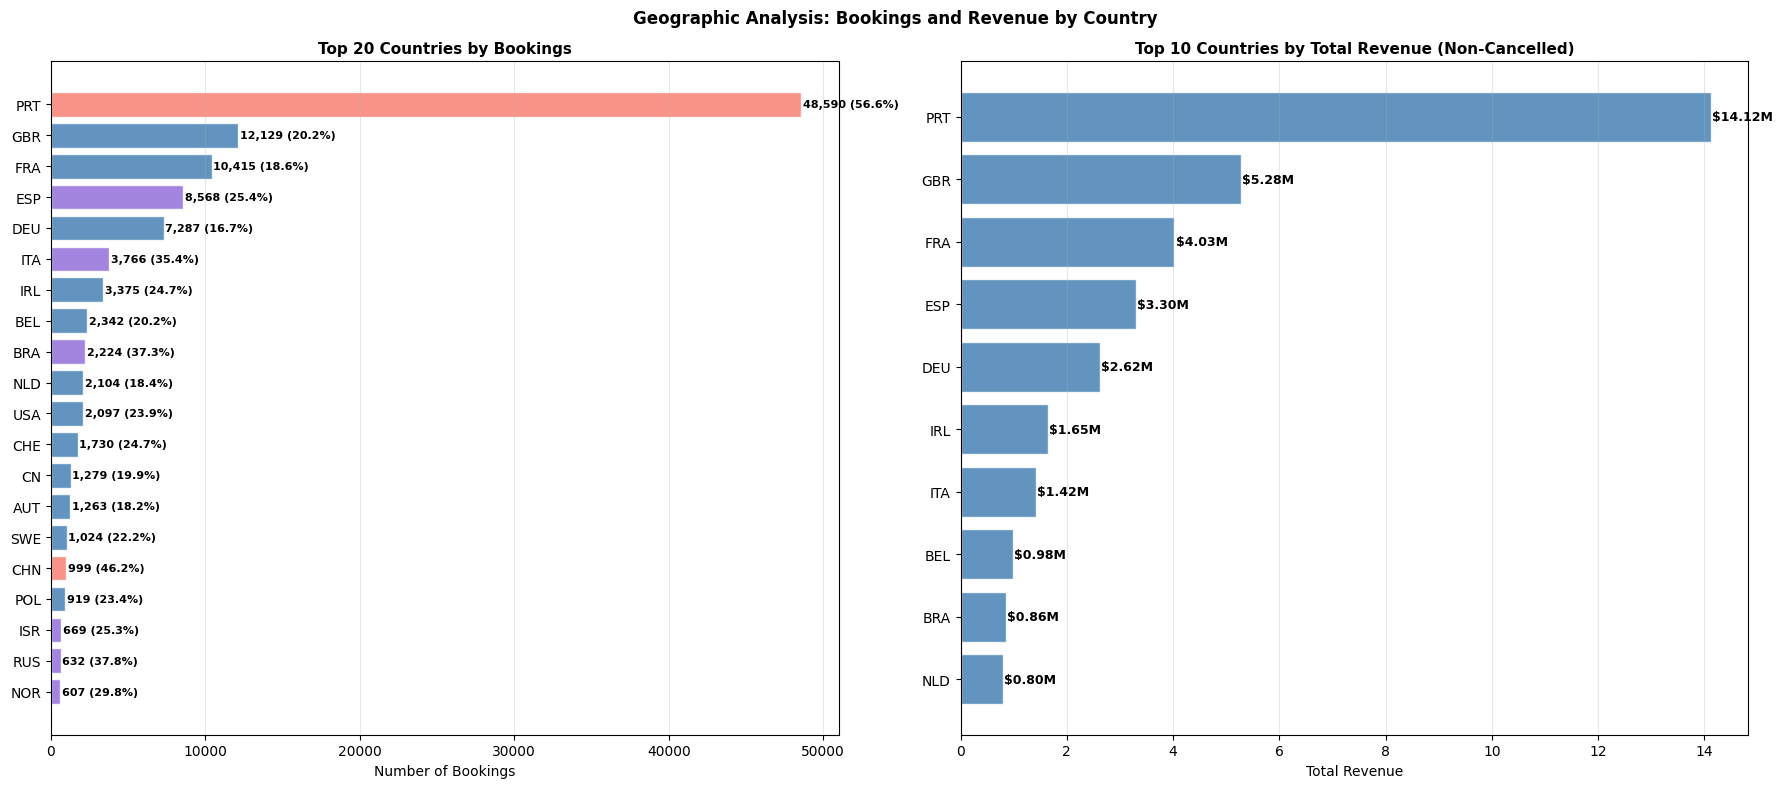

In [74]:
# 4.6.1 Top 20 Countries by Bookings

country_stats = (df.groupby('country')
                   .agg(bookings=('booking_id','count'),
                        cancellations=('is_canceled','sum'),
                        cancel_rate=('is_canceled','mean'),
                        mean_adr=('adr','mean'),
                        total_revenue=('total_revenue','sum'))
                   .reset_index())
country_stats['cancel_rate'] *= 100
country_stats['total_revenue_m'] = country_stats['total_revenue'] / 1_000_000
country_stats = country_stats[country_stats['country'] != 'Unknown']
top20 = country_stats.nlargest(20, 'bookings')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: top 20 by bookings with cancel rate overlay
colors_vol = ['salmon' if r > 40 else
              'steelblue' if r < 25 else
              'mediumpurple'
              for r in top20['cancel_rate']]

bars = axes[0].barh(top20['country'][::-1],
                    top20['bookings'][::-1],
                    color=colors_vol[::-1],
                    edgecolor='white', alpha=0.85)
for bar, val, rate in zip(bars,
                           top20['bookings'][::-1],
                           top20['cancel_rate'][::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({rate:.1f}%)',
                 va='center', fontsize=8, fontweight='bold')

axes[0].set_title('Top 20 Countries by Bookings',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of Bookings')
axes[0].grid(axis='x', alpha=0.3)

# Right: top 10 by total revenue
top10_rev = country_stats.nlargest(10, 'total_revenue')
bars2 = axes[1].barh(top10_rev['country'][::-1],
                     top10_rev['total_revenue_m'][::-1],
                     color='steelblue', edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, top10_rev['total_revenue_m'][::-1]):
    axes[1].text(bar.get_width() + 0.02,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:.2f}M', va='center',
                 fontsize=9, fontweight='bold')
axes[1].set_title('Top 10 Countries by Total Revenue (Non-Cancelled)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Total Revenue')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Geographic Analysis: Bookings and Revenue by Country',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


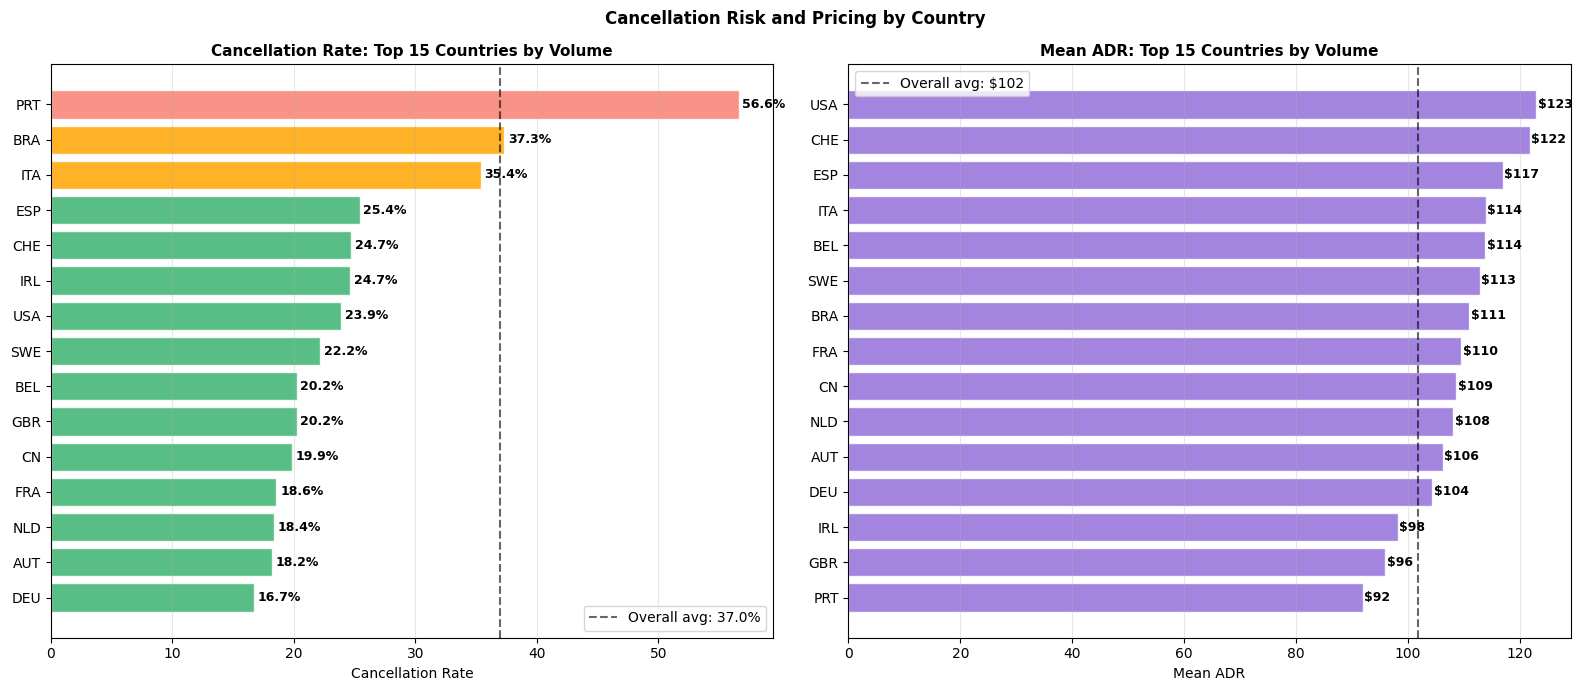

In [77]:
# 4.6.2 Cancellation Rate, Top Countries

top15_vol = country_stats.nlargest(15, 'bookings')
top15_vol = top15_vol.sort_values('cancel_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: cancellation rate for top 15 countries
colors_cancel = ['salmon' if r > 50 else
                 'orange' if r > 35 else
                 'mediumseagreen'
                 for r in top15_vol['cancel_rate']]

bars = axes[0].barh(top15_vol['country'][::-1],
                    top15_vol['cancel_rate'][::-1],
                    color=colors_cancel[::-1],
                    edgecolor='white', alpha=0.85)
axes[0].axvline(x=37.0, color='black', linestyle='--',
                alpha=0.6, label='Overall avg: 37.0%')
for bar, val in zip(bars, top15_vol['cancel_rate'][::-1]):
    axes[0].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center',
                 fontsize=9, fontweight='bold')
axes[0].set_title('Cancellation Rate: Top 15 Countries by Volume',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cancellation Rate')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)


top15_adr = top15_vol.sort_values('mean_adr', ascending=False)
bars2 = axes[1].barh(top15_adr['country'][::-1],
                     top15_adr['mean_adr'][::-1],
                     color='mediumpurple',
                     edgecolor='white', alpha=0.85)
axes[1].axvline(x=df['adr'].mean(), color='black',
                linestyle='--', alpha=0.6,
                label=f"Overall avg: ${df['adr'].mean():.0f}")
for bar, val in zip(bars2, top15_adr['mean_adr'][::-1]):
    axes[1].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:.0f}', va='center',
                 fontsize=9, fontweight='bold')
axes[1].set_title('Mean ADR: Top 15 Countries by Volume',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean ADR')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Cancellation Risk and Pricing by Country',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

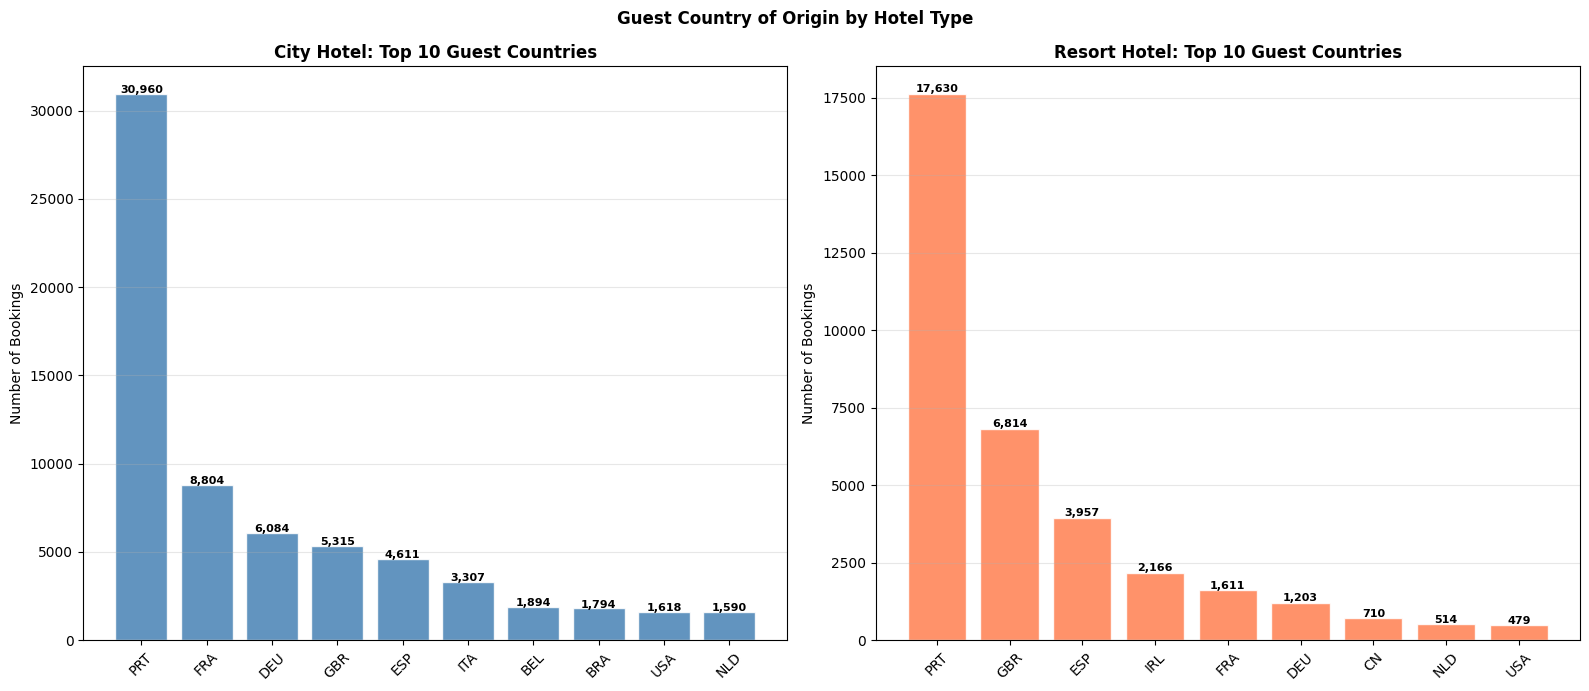

In [79]:
# 4.6.3 Guest Origin Mix by Hotel Type

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, hotel in enumerate(['City Hotel', 'Resort Hotel']):
    top10 = (df[df['hotel'] == hotel]
             .groupby('country')['booking_id']
             .count()
             .sort_values(ascending=False)
             .head(10)
             .reset_index())
    top10.columns = ['country', 'bookings']
    top10 = top10[top10['country'] != 'Unknown']

    colors_h = ['steelblue' if i == 0 else 'coral'] * len(top10)
    bars = axes[i].bar(top10['country'], top10['bookings'],
                       color=colors_h, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, top10['bookings']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 50,
                     f'{val:,}', ha='center',
                     fontsize=8, fontweight='bold')
    axes[i].set_title(f'{hotel}: Top 10 Guest Countries',
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Number of Bookings')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Guest Country of Origin by Hotel Type',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Section 4.6 Findings:**
- Portugal (PRT) dominates with 48,590 bookings (41% of dataset) and $14.12M revenue, but cancels at 56.6%, far above the 37% average
- International guests from DEU (16.7%), FRA (18.6%), NLD (18.4%) cancel at less than half the Portuguese rate, international guests are significantly more reliable than domestic guests
- USA ($123) and CHE ($122) pay the highest ADR while cancelling at low rates, ideal guest profile combining high value and low risk
- PRT pays the lowest ADR ($92) among top countries despite being the largest segment, high volume but low value and high risk
- Resort Hotel attracts more British tourists (GBR 6,814 vs City's 3,325) reflecting its beach/leisure positioning vs City Hotel's domestic business focus
- Targeting high-ADR, low-cancellation international markets (USA, CHE, DEU) through specific marketing campaigns would improve both revenue quality and cancellation risk profile simultaneously

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Section 5 Key Findings Summary

Top Findings by Section:

**4.1 Booking Timeline**
- October is peak booking month (6,203 in 2016) reflecting Portugal's popular shoulder season, not summer as commonly assumed
- City Hotel books further in advance (110 days) vs Resort Hotel (93 days)
- Cancellation rate is flat year-round at about 37%, not a seasonal problem but a structural one requiring permanent intervention

**4.2 Hotel Type Performance**
- Resort Hotel generates higher revenue per completed booking ($400.9 vs $311.4) despite lower ADR, because longer stays (4.3 vs 3.0 nights) outweigh the rate disadvantage
- Resort Hotel ADR reaches $186 in Summer vs City Hotel $115, but collapses to $57 in Winter, creating extreme seasonal vulnerability
- City Hotel cancellation rate exceeds 37% every single month, a structural problem not addressable by seasonal adjustments alone

**4.3 Market Segment and Channel**
- Online TA accounts for 47% of bookings and 54% of revenue ($13.7M) but generates $10.2M in lost cancellation revenue
- Direct bookings match Online TA ADR ($114 vs $114) with half the cancellation rate (15.3% vs 36.7%) and zero OTA commission, making it the single highest-ROI channel strategy available
- Groups segment has the worst risk-return profile: lowest ADR ($79) combined with highest cancellation rate (61.1%)

**4.4 Cancellation Deep Dive**
- Special requests are the strongest commitment signal: 0 requests gives 47.7% cancellation vs 16.8% for 3 or more requests, a 31 point gap
- Online TA alone accounts for $10.2M (61%) of all cancellation revenue loss
- Cancellation volume grows year-over-year as total bookings grow, the problem scales with success unless structurally addressed

**4.5 Revenue and Pricing**
- Price tier does not predict cancellation: Budget (34.2%), Mid (38.4%), and Premium (38.1%) cancel at virtually identical rates
- Summer generates 45% of annual revenue ($11.6M), a dangerous concentration in a single season
- City Hotel total revenue ($14.4M) exceeds Resort ($11.6M) through volume advantage despite ADR disadvantage

**4.6 Geographic Analysis**
- Portugal (PRT) is the largest market (41% of bookings) but worst performing on quality: lowest ADR ($92) and highest cancellation (56.6%)
- USA ($123 ADR, 23.9% cancellation) and DEU ($104 ADR, 16.7% cancellation) represent the ideal guest profile combining premium rates with low cancellation risk
- International guests consistently cancel at lower rates than domestic Portuguese guests across all top markets

Strategic Recommendations:

**Priority 1 Direct Booking Conversion**
Direct bookings match OTA ADR ($114) with 15.3% cancellation vs 36.7% and zero commission. Shifting 10,000 bookings from OTA to Direct would generate approximately $1.5M in saved commission annually.

**Priority 2 Lead Time Deposit Policy**
Implement tiered deposit requirements based on lead time:
- 0 to 30 days: no deposit required (6.8 to 27.9% cancellation)
- 31 to 90 days: refundable deposit (37.7% cancellation)
- 90 or more days: non-refundable or larger deposit (44.7 to 57.0%)

**Priority 3 Special Request Engagement**
Guests with zero special requests cancel at 47.7%. Proactively soliciting preferences at booking converts passive reservations into committed stays.

**Priority 4 International Market Development**
Target USA, DEU, and CHE with specific marketing. These markets combine premium ADR ($104 to $123) with low cancellation rates (16 to 24%). Reducing PRT dependency from 41% to 35% would significantly improve the overall cancellation rate.

**Priority 5 Resort Hotel Off-Season Strategy**
Resort Hotel Winter ADR ($57) vs Summer ($186) creates a 170% swing and serious cash flow risk. Develop conference packages, wellness retreats, and shoulder-season promotions to raise Winter ADR toward $80+.